# part 1: bigram counting method

## playing with names

In [118]:
names = open('names.txt', 'r').read().splitlines()
names[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [119]:
m1 = min(len(name) for name in names)
m2 = max(len(name) for name in names)
m1, m2

(2, 15)

## counting

In [120]:
DOT = '.'
chars = ['.'] + sorted(list(set(''.join(names))))
print(chars)

stoi = {s: i for i, s in enumerate(chars)}
print(stoi)
itos = {i: s for s, i in stoi.items()}
print(itos)

for name in names[:2]:
    name = DOT + name + DOT
    for c1, c2 in zip(name, name[1:]):
        print(c1, c2)

['.', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
{'.': 0, 'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26}
{0: '.', 1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z'}
. e
e m
m m
m a
a .
. o
o l
l i
i v
v i
i a
a .


In [121]:
import torch

In [122]:
# torch.Size([2]) 和 torch.Size([2, 1]) 的区别是：前者是一维向量，后者是二维矩阵，只是第二维长度为 1。

# 用具体值看：

# a = torch.tensor([
#     [1, 2, 3],
#     [4, 5, 6],
# ])

# s1 = torch.sum(a, dim=1)
# print(s1)
# print(s1.shape)

# 输出：

# tensor([ 6, 15])
# torch.Size([2])

# 这是 1D tensor：

# [6, 15]

# 而：

# s2 = torch.sum(a, dim=1, keepdim=True)
# print(s2)
# print(s2.shape)

# 输出：

# tensor([[ 6],
#         [15]])
# torch.Size([2, 1])

# 这是 2D tensor：
#
# [
# [6],
# [15]
# ]

# 可以这样理解：

# torch.Size([2])    -> 只有一个轴，长度为 2
# torch.Size([2, 1]) -> 有两个轴，第 0 维长度为 2，第 1 维长度为 1

# 为什么需要保留 [2, 1]？主要是为了后续 broadcasting。
a = torch.randn(4, 4)
print(a)
print(torch.sum(a, 1, keepdim=True))
print(torch.sum(a, 1, keepdim=True).shape)
print(torch.sum(a, 1, keepdim=False))
print(torch.sum(a, 1, keepdim=False).shape)
print(torch.sum(a))

tensor([[ 0.2844,  0.4074,  1.6864, -1.6698],
        [-0.0887,  1.4189,  0.1849, -1.3127],
        [-1.2628, -2.8495, -0.0223,  0.4259],
        [ 0.2571,  0.4341, -0.9598,  0.9806]])
tensor([[ 0.7084],
        [ 0.2023],
        [-3.7087],
        [ 0.7120]])
torch.Size([4, 1])
tensor([ 0.7084,  0.2023, -3.7087,  0.7120])
torch.Size([4])
tensor(-2.0861)


In [123]:
# 27 * 27 matrix for transition counts
counting = torch.ones((len(chars), len(chars)), dtype=torch.int32)

for name in names:
    name = DOT + name + DOT
    for c1, c2 in zip(name, name[1:]):
        i, j = stoi[c1], stoi[c2]
        counting[i, j] += 1

print(counting)

# convert to probabilities
probs = counting.float()
probs /= probs.sum(1, keepdim=True)
print(probs[0])
print(sum(probs[6]))
print(probs)

tensor([[   1, 4411, 1307, 1543, 1691, 1532,  418,  670,  875,  592, 2423, 2964,
         1573, 2539, 1147,  395,  516,   93, 1640, 2056, 1309,   79,  377,  308,
          135,  536,  930],
        [6641,  557,  542,  471, 1043,  693,  135,  169, 2333, 1651,  176,  569,
         2529, 1635, 5439,   64,   83,   61, 3265, 1119,  688,  382,  835,  162,
          183, 2051,  436],
        [ 115,  322,   39,    2,   66,  656,    1,    1,   42,  218,    2,    1,
          104,    1,    5,  106,    1,    1,  843,    9,    3,   46,    1,    1,
            1,   84,    1],
        [  98,  816,    1,   43,    2,  552,    1,    3,  665,  272,    4,  317,
          117,    1,    1,  381,    2,   12,   77,    6,   36,   36,    1,    1,
            4,  105,    5],
        [ 517, 1304,    2,    4,  150, 1284,    6,   26,  119,  675,   10,    4,
           61,   31,   32,  379,    1,    2,  425,   30,    5,   93,   18,   24,
            1,  318,    2],
        [3984,  680,  122,  154,  385, 1272,   83,

In [124]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
%matplotlib inline

(-0.5, 26.5, 26.5, -0.5)

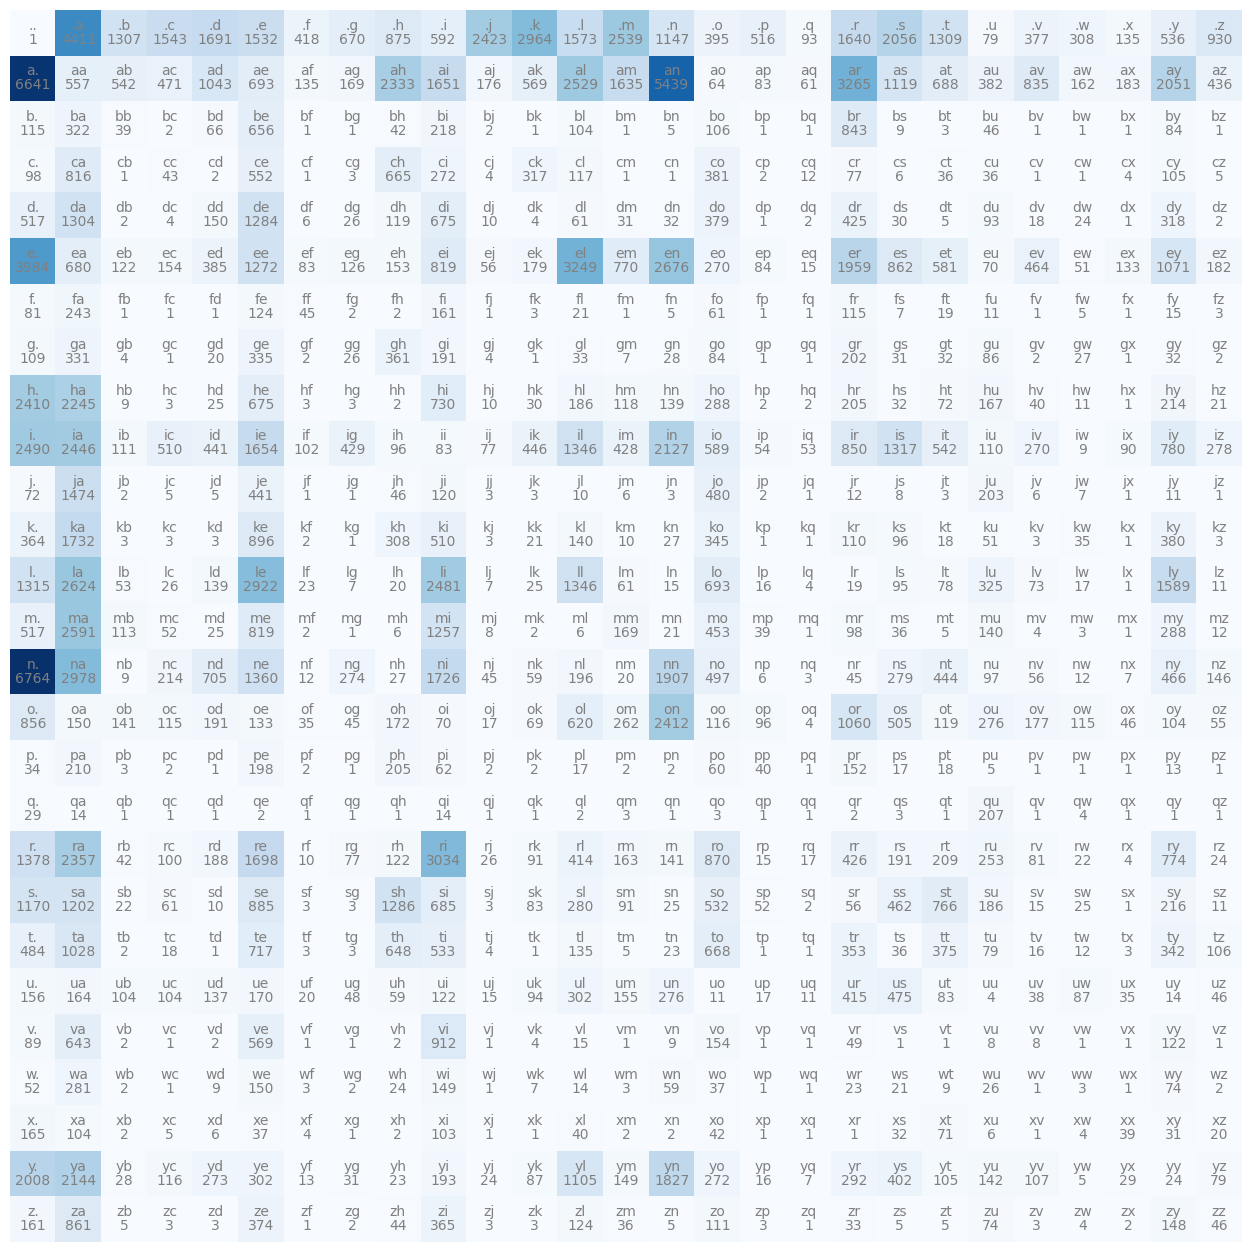

In [125]:
plt.figure(figsize=(16,16))
plt.imshow(counting, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, counting[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off')

In [126]:
counting[0], counting[0].shape   

(tensor([   1, 4411, 1307, 1543, 1691, 1532,  418,  670,  875,  592, 2423, 2964,
         1573, 2539, 1147,  395,  516,   93, 1640, 2056, 1309,   79,  377,  308,
          135,  536,  930], dtype=torch.int32),
 torch.Size([27]))

In [127]:
p = counting[0].float()
p /= p.sum()
p_rounded = torch.round(p, decimals=4)
p_rounded

tensor([0.0000, 0.1376, 0.0408, 0.0481, 0.0527, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0185, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0641, 0.0408, 0.0025, 0.0118, 0.0096, 0.0042, 0.0167, 0.0290])

In [128]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=5, replacement=True, generator=g)
ix, [itos[i.item()] for i in ix]

(tensor([13, 19, 14,  1,  1]), ['m', 's', 'n', 'a', 'a'])

In [129]:
g = torch.Generator().manual_seed(2147483647)

for i in range(10):
    out = []
    ix = 0 # start from the start token character
    while True:
        p = counting[ix].float()
        p = p / p.sum()
        ix = torch.multinomial(p,num_samples=1, replacement = True, generator = g).item()
        out.append(itos[ix])
        if ix == 0: # If it is the end token character break the loop
            break
    print("".join(out))

junide.
janasah.
p.
cony.
a.
nn.
kohin.
tolian.
juee.
ksahnaauranilevias.


In [130]:
log_likelihood = 0.0
n = 0
for w in ["andrejq"]:
    chs = ['.'] + list(w) + ['.'] 
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        t = probs[ix1, ix2]
        logprob = torch.log(t)
        log_likelihood += logprob
        n += 1
        print(f'{ch1}{ch2}: {t:.4f} {logprob:.4f}')
        
print(f'\nlog_likelihood = {log_likelihood:.4f}')
nll = -log_likelihood
print(f'negative log_likelihood = {nll:.4f}')
avg_nll = nll/n
print(f'average negative log_likelihood = {avg_nll:.4f}')

.a: 0.1376 -1.9835
an: 0.1604 -1.8302
nd: 0.0384 -3.2594
dr: 0.0770 -2.5646
re: 0.1334 -2.0143
ej: 0.0027 -5.9004
jq: 0.0003 -7.9817
q.: 0.0970 -2.3331

log_likelihood = -27.8672
negative log_likelihood = 27.8672
average negative log_likelihood = 3.4834


In [131]:
# The bigram model is estimated from training counts:
#   counts[i, j] = how many times character j follows character i
#   probs[i, j] = P(j | i)
#
# When computing the NLL loss, we still evaluate every observed bigram occurrence,
# not only every unique (c1, c2) pair.
#
# This can look like "double counting" because probs are estimated from the same
# training data, then evaluated on that same data. But it is exactly the maximum
# likelihood objective:
#   likelihood = Π_t P(next_t | current_t)
#   log_likelihood = Σ_t log P(next_t | current_t)
#   nll = -mean_t log P(next_t | current_t)
#
# Therefore frequent bigrams must appear more times in the loss. For example, if
# a -> n appears 1000 times and a -> z appears 2 times, the loss should contain:
#   1000 * log P(n | a) + 2 * log P(z | a)
# Using set((c1, c2)) would remove frequency information and incorrectly give
# rare and frequent transitions the same weight.
#
# This counting bigram model is still a statistical/probability model, not a
# neural network: probs come directly from normalized counts, so there is no
# parameter gradient/update here. It mainly provides a baseline and introduces
# the language-modeling objective before the neural-network version.
xs , ys = [], []
for name in names:
    name = DOT + name + DOT
    for c1, c2 in zip(name, name[1:]):
        i, j = stoi[c1], stoi[c2]
        xs.append(i)
        ys.append(j)

bigram_prob = probs[xs, ys]
loss = -bigram_prob.log().mean()
print(loss)

tensor(2.4546)


# part 2: gradient approach

In [132]:
xs, ys = [], []
for w in names[:1]:
    chs = ['.'] + list(w) + ['.'] 
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        print(ch1, ch2)
        xs.append(ix1)
        ys.append(ix2)
        
xs = torch.tensor(xs) # use .tensor for integer data types (.Tensor gives float datatype)
ys = torch.tensor(ys)

. e
e m
m m
m a
a .


In [133]:
xs, ys

(tensor([ 0,  5, 13, 13,  1]), tensor([ 5, 13, 13,  1,  0]))

In [134]:
xs.shape, xs.dtype

(torch.Size([5]), torch.int64)

In [135]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).float()
xenc, xenc.shape, xenc.dtype

(tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0.]]),
 torch.Size([5, 27]),
 torch.float32)

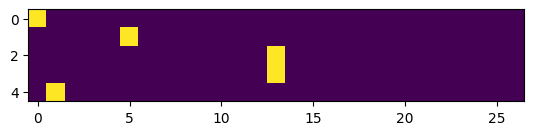

In [136]:
plt.imshow(xenc)

## neural net

In [137]:
W = torch.randn((27, 1))
xenc @ W, (xenc @ W).shape

(tensor([[ 0.9950],
         [-1.5070],
         [-0.8103],
         [-0.8103],
         [-1.5318]]),
 torch.Size([5, 1]))

In [138]:
W = torch.randn((27, 27))
xenc @ W, (xenc @ W).shape

(tensor([[-0.3359, -2.0415, -1.2193, -0.3536, -1.4723, -1.1142,  0.5515,  1.1117,
          -0.0669, -0.7660,  0.6914, -1.0501,  0.1602, -0.0637,  1.2302, -0.8752,
           2.3187, -2.0289,  0.2699,  0.1583,  0.9729, -0.9922,  0.4226,  0.2902,
           1.2608,  0.2914, -0.1287],
         [-0.1104,  1.2506, -1.2910,  0.0654, -1.7493, -0.1409,  0.2587,  0.8231,
           0.3541, -0.9113,  1.0955,  2.1147, -0.9134,  0.6886,  0.3252,  1.2374,
           0.6561,  0.0513, -0.0776,  1.2076, -0.5525, -0.0826, -0.7552, -0.8982,
          -1.6550, -0.1177,  1.1863],
         [-0.7669,  0.1609,  0.3072,  0.1189, -2.3267,  1.1502,  1.2333, -1.7237,
           0.4422, -1.2573, -0.0850, -0.7528, -0.6797, -0.8655, -0.5672, -2.1755,
           3.1473,  2.8334,  0.0830, -0.8134, -0.8686,  0.9814, -0.2133,  0.7089,
           1.6563, -0.8701,  0.9793],
         [-0.7669,  0.1609,  0.3072,  0.1189, -2.3267,  1.1502,  1.2333, -1.7237,
           0.4422, -1.2573, -0.0850, -0.7528, -0.6797, -0.8655, -0

In [139]:
(xenc @ W)[3, 13] 

tensor(-0.8655)

In [140]:
xenc[3]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [141]:
W[:, 13]

tensor([-0.0637, -0.4537, -0.3837,  1.6304, -0.0729,  0.6886,  0.3378, -0.2689,
        -0.5777, -0.1235, -1.1231, -1.0345, -1.8446, -0.8655, -0.4935, -0.8719,
        -0.2594,  0.1658,  1.2088,  0.2248, -2.4992,  0.2395, -0.0648,  0.8140,
        -0.6205, -0.0416,  0.4565])

In [142]:
(xenc[3] * W[:, 13]).sum()

tensor(-0.8655)

## softmax

In [143]:
logits = xenc @ W                               # log-count
counts = logits.exp()                           # equivalent to N
probs = counts / counts.sum(1, keepdims=True)   # probabilities for next character
probs

tensor([[0.0173, 0.0031, 0.0072, 0.0170, 0.0056, 0.0080, 0.0421, 0.0736, 0.0227,
         0.0113, 0.0484, 0.0085, 0.0284, 0.0227, 0.0829, 0.0101, 0.2462, 0.0032,
         0.0317, 0.0284, 0.0641, 0.0090, 0.0370, 0.0324, 0.0855, 0.0324, 0.0213],
        [0.0201, 0.0782, 0.0062, 0.0239, 0.0039, 0.0195, 0.0290, 0.0510, 0.0319,
         0.0090, 0.0670, 0.1856, 0.0090, 0.0446, 0.0310, 0.0772, 0.0432, 0.0236,
         0.0207, 0.0749, 0.0129, 0.0206, 0.0105, 0.0091, 0.0043, 0.0199, 0.0733],
        [0.0065, 0.0163, 0.0189, 0.0157, 0.0014, 0.0439, 0.0478, 0.0025, 0.0216,
         0.0040, 0.0128, 0.0066, 0.0070, 0.0059, 0.0079, 0.0016, 0.3238, 0.2365,
         0.0151, 0.0062, 0.0058, 0.0371, 0.0112, 0.0283, 0.0729, 0.0058, 0.0370],
        [0.0065, 0.0163, 0.0189, 0.0157, 0.0014, 0.0439, 0.0478, 0.0025, 0.0216,
         0.0040, 0.0128, 0.0066, 0.0070, 0.0059, 0.0079, 0.0016, 0.3238, 0.2365,
         0.0151, 0.0062, 0.0058, 0.0371, 0.0112, 0.0283, 0.0729, 0.0058, 0.0370],
        [0.0099, 0.0580,

In [144]:
probs[0].sum(), probs[3].sum(), probs[:,3].sum()

(tensor(1.), tensor(1.), tensor(0.0879))

## summary

In [145]:
xs

tensor([ 0,  5, 13, 13,  1])

In [146]:
ys

tensor([ 5, 13, 13,  1,  0])

In [147]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g)

In [148]:
xenc = F.one_hot(xs, num_classes=27).float()  # input to the network: one-hot encoding
logits = xenc @ W                             # predict log-counts
counts = logits.exp()                         # counts, equivalent to N
probs = counts / counts.sum(1, keepdims=True) # probabilities for next character

In [149]:
probs.shape

torch.Size([5, 27])

In [150]:
nlls = torch.zeros(5)
for i in range(5):
    # i-th bigram:
    x = xs[i].item() # input character index
    y = ys[i].item() # label character index
    print('--------\n')
    print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
    print('input to the neural net:', x)
    print('output probabilities from the neural net:', probs[i])
    print('label (actual next character):', y)
    p = probs[i, y]
    print('probability assigned by the net to the the correct character:', p.item())
    logp = torch.log(p)
    print('log likelihood:', logp.item())
    nll = -logp
    print('negative log likelihood:', nll.item())
    nlls[i] = nll

print('\n=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

--------

bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459])
label (actual next character): 5
probability assigned by the net to the the correct character: 0.01228625513613224
log likelihood: -4.399273872375488
negative log likelihood: 4.399273872375488
--------

bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
        0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
        0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472])
label (actual next character): 13
probability assigned by the net to the the correct character: 

## vectorized loss

In [151]:
probs.shape

torch.Size([5, 27])

In [152]:
probs[0, 5], probs[1, 13], probs[2, 13], probs[3, 1], probs[4, 0]

(tensor(0.0123),
 tensor(0.0181),
 tensor(0.0267),
 tensor(0.0737),
 tensor(0.0150))

In [153]:
torch.arange(5)

tensor([0, 1, 2, 3, 4])

In [154]:
loss = -probs[torch.arange(5), ys].log().mean()
loss

tensor(3.7693)

In [155]:
## backward pass

In [156]:
xs, ys

(tensor([ 0,  5, 13, 13,  1]), tensor([ 5, 13, 13,  1,  0]))

In [157]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

In [158]:
xenc = F.one_hot(xs, num_classes=27).float()  # input to the network: one-hot encoding
logits = xenc @ W                             # predict log-counts
counts = logits.exp()                         # counts, equivalent to N
probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
loss = -probs[torch.arange(5), ys].log().mean()
print((loss.item()))

3.7693049907684326


In [159]:
W.grad = None     # set gradient to zero
loss.backward()

W.data += -0.1 * W.grad

In [ ]:
## all together

In [164]:
xs, ys = [], []
for w in names:
    chs = ['.'] + list(w) + ['.'] 
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)

num = len(xs)
print(num)

g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

for i in range(1):
    xenc = F.one_hot(xs, num_classes=27).float()  # input to the network: one-hot encoding
    logits = xenc @ W                             # predict log-counts
    counts = logits.exp()                         # counts, equivalent to N
    probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
    loss = -probs[torch.arange(num), ys].log().mean()
    print(i, loss.item())

    W.grad = None     # set gradient to zero
    loss.backward()

    W.data += -50 * W.grad


228146
0 3.758953809738159


In [ ]:
def train_NN(n_iter=100, lr=50):
    losses, steps = [], []
    # gradient descent
    for k in range(n_iter):
        steps.append(k+1)
        
        # forward pass
        xenc = F.one_hot(xs, num_classes=27).float()  # input to the network: one-hot encoding
        logits = xenc @ W                             # predict log-counts
        counts = logits.exp()                         # counts, equivalent to N
        probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
        # loss = -probs[torch.arange(num), ys].log().mean()
        # 2.458071231842041
        # tensor(4.4681, grad_fn=<MaxBackward1>) tensor(-3.7104, grad_fn=<MinBackward1>) tensor(0.0111, grad_fn=<MeanBackward0>) tensor(1.2891, grad_fn=<MeanBackward0>)
        loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()
        # 2.48089861869812
        # tensor(4.3226, grad_fn=<MaxBackward1>) tensor(-3.5538, grad_fn=<MinBackward1>) tensor(0.0097, grad_fn=<MeanBackward0>) tensor(1.2318, grad_fn=<MeanBackward0>)
        losses.append(loss.item())

        # backward pass
        W.grad = None # set to zero the gradient
        loss.backward()

        # update
        W.data += -lr * W.grad
    return [steps, losses]

In [189]:
_train_loss = train_NN()

2.48089861869812
tensor(4.3226, grad_fn=<MaxBackward1>) tensor(-3.5538, grad_fn=<MinBackward1>) tensor(0.0097, grad_fn=<MeanBackward0>) tensor(1.2318, grad_fn=<MeanBackward0>)


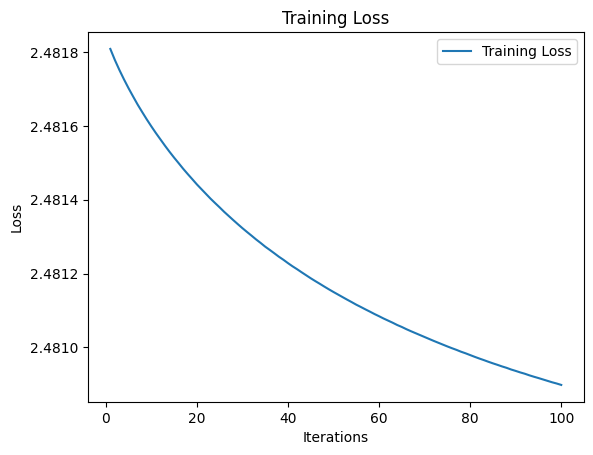

In [190]:
# Retrieve each dictionary's values
train_values = _train_loss[1]
print(train_values[99])
print(W.max(), W.min(), W.mean(), W.abs().mean())
 
# Generate a sequence of integers to represent the iteration numbers
n_iter = _train_loss[0]
 
# Plot and label the training and validation loss values
plt.plot(n_iter, train_values, label='Training Loss')
 
# Add in a title and axes labels
plt.title('Training Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
 
# Set the tick locations
# plt.xticks(np.arange(0, 21, 2))
 
# Display the plot
plt.legend(loc='best')
plt.show()

In [195]:
# finally, sample from the 'neural net' model
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
  
    out = []
    ix = 0
    while True:
        xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
        logits = xenc @ W # predict log-counts
        counts = logits.exp() # counts, equivalent to N
        p = counts / counts.sum(1, keepdims=True) # probabilities for next character

        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

junide.
janasah.
p.
cony.
a.
